In [25]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))

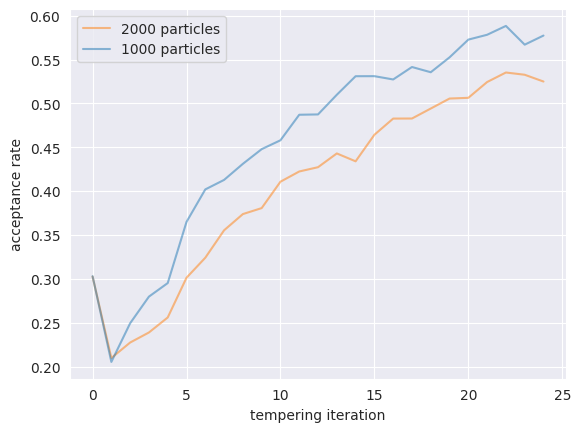

In [26]:
N = np.array([1000, 2000])
palette = sns.color_palette(None, len(N))
palette_dict = dict(zip(N, palette))

for idx, pkl in enumerate(PKLs):
    num_particles = pkl['config']['num_particles']
    plt.plot(pkl['acceptance_rate'].mean(axis=-1), alpha=0.5, label=f'{num_particles} particles',  c=palette_dict[num_particles])
plt.ylabel("acceptance rate")
plt.xlabel("tempering iteration")
plt.legend()

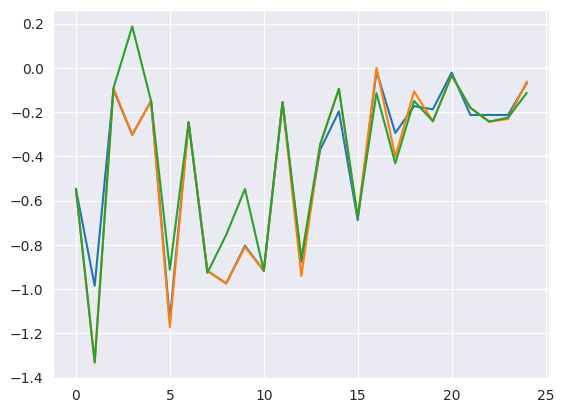

In [54]:
plt.plot(pkl['update_info'].proposal.position[0][0,...,0][:,0,:])

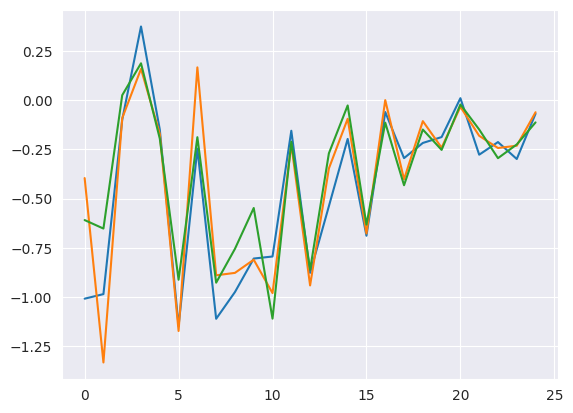

In [49]:
plt.plot(pkl['update_info'].proposed_states.position[0][0,..., 0][:,0,:])

In [51]:
pkl['update_info'].proposed_states.position[0][0,..., 0][:,0,:].shape

(25, 3)

In [ ]:
N = np.array([60, 100, 200, 500, 1000])
period_max = np.array([1, 2, 3])
palette = sns.color_palette(None, len(N))
palette_dict = dict(zip(N, palette))
linstyles = ['dotted', 'dashdot', 'dashed', 'solid']
linstyles_dict = dict(zip(period_max, linstyles))

for idx, pkl in enumerate(PKLs):
    if "wf" not in PKL_titles[idx]:
        num_particles = pkl['config']['num_particles']
        period_max = pkl['config']['params_proposal'][1]
        if period_max == 1:
            plt.plot(pkl['acceptance_rate'].mean(axis=-1), alpha=0.5, linestyle=linstyles_dict[period_max], c=palette_dict[num_particles])
        else:
            plt.plot(pkl['acceptance_rate'].mean(axis=-1), label=(f'{num_particles}'), linestyle=linstyles_dict[period_max], alpha=0.5, c=palette_dict[num_particles])
plt.legend()

In [ ]:
PKLs[0]['acceptance_rate']

In [ ]:
PKL_titles

In [ ]:
plt.plot(PKLs[0]['acceptance_ratio'][0][0])

In [ ]:
PKLs[0].keys()

In [58]:
pkl

dict_keys(['title', 'config', 'acceptance_rate', 'update_info', 'esjd', 'logZ_logW', 'lmbda', 'paths'])